## 1. LOAD BUILT HYPERGRAPH TABLES

The input tables are treated as a long incidence table : each row represents one membership between a patient hyperedge and a diagnosis vertex. This follows the hypergraph representation, where a hypergraph is described by a vertex set, a hyperedge set, and the incidence relation between them.

In [53]:
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations, product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)#
pd.set_option("display.max_colwidth", 120)#

OUTPUT_DIR = Path("descriptive_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# these can be changed to analyse a subgroup.
SEX_FILTER = "All"       # "All", "Male", "Female"
AGE_FILTER = "All"       # "All", "20-29", ..., "70+"

In [54]:
male = pd.read_csv("male_hyperedge_table.csv", parse_dates=["first_date"])
female = pd.read_csv("female_hyperedge_table.csv", parse_dates=["first_date"])
hypergraph_table = pd.concat([male, female], ignore_index=True)

## 2. prepare dates, age groups, diagnosis lookup, and patient lookup


In [55]:
hypergraph_table["first_date"] = pd.to_datetime(
    hypergraph_table["first_date"], errors="coerce"
).dt.normalize()

hypergraph_table["age_start"] = pd.to_numeric(
    hypergraph_table["age_group"].astype(str).str.extract(r"(\d+)", expand=False),
    errors="coerce"
)

hypergraph_table["age_group_10y"] = pd.cut(
    hypergraph_table["age_start"],
    bins=[20, 30, 40, 50, 60, 70, np.inf],
    labels=["20-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
)

node_lookup = (
    hypergraph_table[["node_id", "diagnose_id", "icd_code", "descr"]]
    .drop_duplicates("node_id")
    .set_index("node_id")
)

patient_info = (
    hypergraph_table[["patient_no", "sex_id", "sex", "age_group", "age_group_10y"]]
    .drop_duplicates("patient_no")
)


In [56]:
# function for selecting cohort (sex/age group)

def select_cohort(df, sex="All", age_group="All", min_unique_diagnoses=1):

    selected = df.copy()
    if sex != "All":
        selected = selected[selected["sex"] == sex]
    if age_group != "All":
        selected = selected[selected["age_group_10y"].astype(str) == age_group]

    # Keep patients with at least one diagnosis node.
    # Pattern size 1 is meaningful because it shows diagnoses that appear alone.
    if min_unique_diagnoses is not None:
        patient_diagnosis_counts = (
            selected.groupby("patient_no")["node_id"]
            .nunique()
            .reset_index(name="n_unique_diagnoses")
        )
        eligible_patients = patient_diagnosis_counts[
            patient_diagnosis_counts["n_unique_diagnoses"] >= min_unique_diagnoses
        ]["patient_no"]

        selected = selected[selected["patient_no"].isin(eligible_patients)]

    return selected.copy()


analysis_table = select_cohort(
    hypergraph_table,
    sex=SEX_FILTER,
    age_group=AGE_FILTER,
    min_unique_diagnoses=1
)

assert analysis_table["patient_no"].nunique() > 0, "Selected cohort is empty."


## 3. show basic hypergraph statistics for all patients, males, and females

This section summarizes the global structure of the selected patient-diagnosis hypergraph. In Dai and Gao's terminology, the hypergraph is represented through vertices, hyperedges, and their incidence structure. Here, diagnosis codes are vertices and patients are hyperedges.

The reported quantities correspond to:

- `n_patient_hyperedges`: number of patient hyperedges;
- `n_diagnosis_nodes`: number of diagnosis vertices;
- `n_memberships`: number of non-zero patient-diagnosis incidences;
- `incidence_density`: observed memberships divided by all possible patient-diagnosis memberships;
- `mean_hyperedge_size`: average number of unique diagnosis vertices per patient hyperedge.

This is the descriptive analogue of working with the hypergraph incidence matrix discussed in the book's graph-versus-hypergraph comparison (Dai & Gao, 2023, Ch. 2, Sec. 2.3.2).



In [57]:
def hypergraph_overview(df):
    """Calculate the main structural statistics of the selected hypergraph table.

    The input table is the long patient-diagnosis membership table:
    one row = one patient-diagnosis membership.

    Hyperedge size is the number of unique diagnosis nodes per patient.
    Incidence density is memberships / (patients * diagnosis nodes).
    """

    n_patients = df["patient_no"].nunique()
    n_nodes = df["node_id"].nunique()
    n_memberships = len(df)
    edge_sizes = df.groupby("patient_no")["node_id"].nunique()
    density = n_memberships / (n_patients * n_nodes)

    return pd.DataFrame([{
        "n_patient_hyperedges": n_patients,
        "n_diagnosis_nodes": n_nodes,
        "n_memberships": n_memberships,
        "incidence_density": round(density, 6),
        "incidence_sparsity": round(1 - density, 6),
        "mean_hyperedge_size": round(edge_sizes.mean(), 1),
        "median_hyperedge_size": edge_sizes.median(),
        "min_hyperedge_size": edge_sizes.min(),
        "max_hyperedge_size": edge_sizes.max()
    }])


## 2b. Sex comparison with all age groups included

The main analysis above uses SEX_FILTER = "All" and AGE_FILTER = "All", so it analyses the complete cohort.

This block additionally repeats the main descriptive summaries separately for:

- all patients
- male patients, all age groups
- female patients, all age groups

So here sex is compared, but age is not filtered.

In [58]:
# Comparative analysis by sex, while keeping all age groups.
# This creates one overview table with All, Male and Female rows.

sex_analysis_tables = {
    "All": select_cohort(hypergraph_table, sex="All", age_group="All"),
    "Male": select_cohort(hypergraph_table, sex="Male", age_group="All"),
    "Female": select_cohort(hypergraph_table, sex="Female", age_group="All")
}

sex_overview_rows = []
sex_edge_size_rows = []
sex_multimorbidity_rows = []
sex_diagnosis_frequency_rows = []

for sex_group, sex_table in sex_analysis_tables.items():
    # Basic hypergraph structure for each sex group.
    overview_part = hypergraph_overview(sex_table)
    overview_part.insert(0, "sex_group", sex_group)
    sex_overview_rows.append(overview_part)

    # Number of unique diagnoses per patient.
    edge_sizes_part = (
        sex_table.groupby("patient_no")["node_id"]
        .nunique()
        .reset_index(name="hyperedge_size")
    )
    edge_sizes_part["sex_group"] = sex_group

    edge_distribution_part = (
        edge_sizes_part.groupby("hyperedge_size")
        .agg(n_patients=("patient_no", "nunique"))
        .reset_index()
    )
    edge_distribution_part["sex_group"] = sex_group
    edge_distribution_part["patient_percent"] = (
        100 * edge_distribution_part["n_patients"]
        / edge_sizes_part["patient_no"].nunique()
    ).round(2)
    sex_edge_size_rows.append(edge_distribution_part)

    # Multimorbidity categories by sex group.
    edge_sizes_part["multimorbidity_group"] = pd.cut(
        edge_sizes_part["hyperedge_size"],
        bins=[0, 1, 4, 9, np.inf],
        labels=["1 diagnosis", "2-4 diagnoses", "5-9 diagnoses", "10+ diagnoses"]
    )
    multimorbidity_part = (
        edge_sizes_part.groupby("multimorbidity_group", observed=False)
        .agg(n_patients=("patient_no", "nunique"))
        .reset_index()
    )
    multimorbidity_part["sex_group"] = sex_group
    multimorbidity_part["patient_percent"] = (
        100 * multimorbidity_part["n_patients"]
        / edge_sizes_part["patient_no"].nunique()
    ).round(2)
    sex_multimorbidity_rows.append(multimorbidity_part)

    # Diagnosis frequency/prevalence by sex group.
    diagnosis_frequency_part = (
        sex_table.groupby(["node_id", "diagnose_id", "icd_code", "descr"])["patient_no"]
        .nunique()
        .reset_index(name="node_degree")
        .sort_values("node_degree", ascending=False)
        .reset_index(drop=True)
    )
    diagnosis_frequency_part["sex_group"] = sex_group
    diagnosis_frequency_part["patient_prevalence_percent"] = (
        100 * diagnosis_frequency_part["node_degree"]
        / sex_table["patient_no"].nunique()
    ).round(2)
    diagnosis_frequency_part["rank_within_sex"] = range(1, len(diagnosis_frequency_part) + 1)
    sex_diagnosis_frequency_rows.append(diagnosis_frequency_part)

sex_overview = pd.concat(sex_overview_rows, ignore_index=True)
sex_hyperedge_size_distribution = pd.concat(sex_edge_size_rows, ignore_index=True)
sex_multimorbidity_summary = pd.concat(sex_multimorbidity_rows, ignore_index=True)
sex_diagnosis_frequency = pd.concat(sex_diagnosis_frequency_rows, ignore_index=True)

sex_top_diagnoses = sex_diagnosis_frequency[
    sex_diagnosis_frequency["rank_within_sex"] <= 20
].copy()

sex_overview.to_csv(OUTPUT_DIR / "hypergraph_overview.csv", index=False)
sex_hyperedge_size_distribution.to_csv(OUTPUT_DIR / "sex_edge_sizes.csv", index=False)
sex_multimorbidity_summary.to_csv(OUTPUT_DIR / "sex_multimorbidity.csv", index=False)
sex_diagnosis_frequency.to_csv(OUTPUT_DIR / "sex_diagnosis_frequency.csv", index=False)
sex_top_diagnoses.to_csv(OUTPUT_DIR / "sex_top_diagnoses.csv", index=False)

sex_overview




,sex_group,n_patient_hyperedges,n_diagnosis_nodes,n_memberships,incidence_density,incidence_sparsity,mean_hyperedge_size,median_hyperedge_size,min_hyperedge_size,max_hyperedge_size
0,All,20131,4388,142679,0.001615,0.998385,7.1,4.0,1,186
1,Male,9422,3695,69355,0.001992,0.998008,7.4,5.0,1,186
2,Female,10709,3714,73324,0.001844,0.998156,6.8,4.0,1,87


## 3. Hyperedge-size distribution and multimorbidity

Hyperedge size is the number of unique diagnoses belonging to one patient.

In [59]:
patient_edge_sizes = (
    analysis_table.groupby("patient_no")["node_id"]
    .nunique()
    .reset_index(name="hyperedge_size")
)

patient_edge_sizes["multimorbidity_group"] = pd.cut(
    patient_edge_sizes["hyperedge_size"],
    bins=[0, 1, 4, 9, np.inf],
    labels=["1 diagnosis", "2-4 diagnoses", "5-9 diagnoses", "10+ diagnoses"]
)

hyperedge_size_distribution = (
    patient_edge_sizes.groupby("hyperedge_size")
    .agg(n_patients=("patient_no", "nunique"))
    .reset_index()
)
hyperedge_size_distribution["patient_percent"] = (
    100 * hyperedge_size_distribution["n_patients"]
    / patient_edge_sizes["patient_no"].nunique()
).round(2)

multimorbidity_summary = (
    patient_edge_sizes.groupby("multimorbidity_group", observed=False)
    .agg(n_patients=("patient_no", "nunique"))
    .reset_index()
)
multimorbidity_summary["patient_percent"] = (
    100 * multimorbidity_summary["n_patients"]
    / patient_edge_sizes["patient_no"].nunique()
).round(2)

hyperedge_size_distribution.to_csv(OUTPUT_DIR / "hyperedge_size_distribution.csv", index=False)
multimorbidity_summary.to_csv(OUTPUT_DIR / "multimorbidity_summary.csv", index=False)
multimorbidity_summary



,multimorbidity_group,n_patients,patient_percent
0,1 diagnosis,26,0.13
1,2-4 diagnoses,10393,51.63
2,5-9 diagnoses,5451,27.08
3,10+ diagnoses,4261,21.17


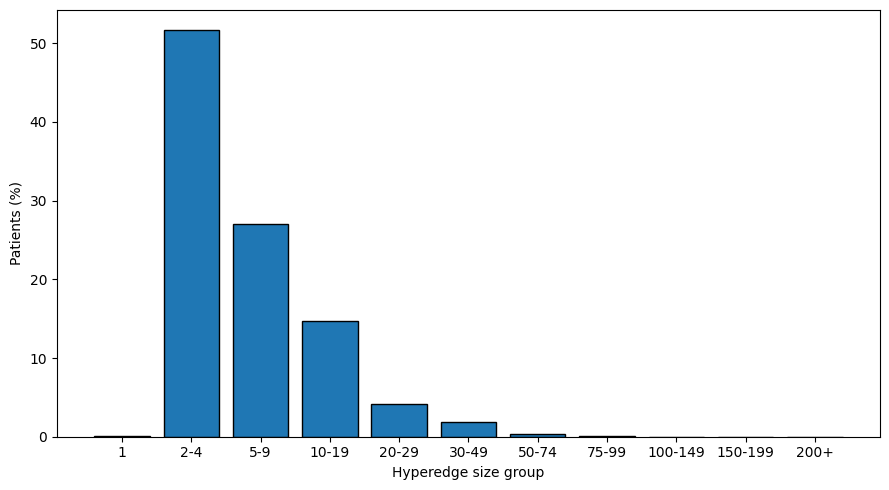

,hyperedge_size_group,n_patients,patient_percent
0,1,26,0.13
1,2-4,10393,51.63
2,5-9,5451,27.08
3,10-19,2965,14.73
4,20-29,838,4.16
5,30-49,384,1.91
6,50-74,65,0.32
7,75-99,6,0.03
8,100-149,1,0.00
9,150-199,2,0.01


In [60]:
bins = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, np.inf]
labels = ["1", "2-4", "5-9", "10-19", "20-29", "30-49", "50-74", "75-99", "100-149", "150-199", "200+"]

patient_edge_sizes["hyperedge_size_group"] = pd.cut(
    patient_edge_sizes["hyperedge_size"],
    bins=bins,
    labels=labels,
    right=False
)

hyperedge_size_binned = (
    patient_edge_sizes.groupby("hyperedge_size_group", observed=False)
    .agg(n_patients=("patient_no", "nunique"))
    .reset_index()
)

hyperedge_size_binned["patient_percent"] = (
    100 * hyperedge_size_binned["n_patients"]
    / patient_edge_sizes["patient_no"].nunique()
).round(2)

hyperedge_size_binned.to_csv(OUTPUT_DIR / "hyperedge_size_binned.csv", index=False)

plt.figure(figsize=(9, 5))
plt.bar(
    hyperedge_size_binned["hyperedge_size_group"].astype(str),
    hyperedge_size_binned["patient_percent"],
    edgecolor="black"
)
plt.xlabel("Hyperedge size group")
plt.ylabel("Patients (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "edge_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

hyperedge_size_binned



## 4. Node-degree distribution and diagnosis prevalence

In hypergraph terminology, this is the **vertex degree** computed from the incidence relation between vertices and hyperedges

For each diagnosis node, counts how many unique patients have that diagnosis. So the top diagnosis nodes are the **most prevalent diagnosis vertices** in the selected cohort



In [61]:
diagnosis_frequency = (
    analysis_table.groupby(["node_id", "diagnose_id", "icd_code", "descr"])["patient_no"]
    .nunique()
    .reset_index(name="node_degree")
    .sort_values("node_degree", ascending=False)
    .reset_index(drop=True)
)

diagnosis_frequency["patient_prevalence_percent"] = (
    100 * diagnosis_frequency["node_degree"]
    / analysis_table["patient_no"].nunique()
).round(2)
diagnosis_frequency.insert(0, "rank", range(1, len(diagnosis_frequency) + 1))
diagnosis_frequency.to_csv(OUTPUT_DIR / "diagnosis_frequency.csv", index=False)
diagnosis_frequency.head(20)
#for each diagnosis node, how many unique patients have that diagnosis



,rank,node_id,diagnose_id,icd_code,descr,node_degree,patient_prevalence_percent
0,1,3103,3703,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,Hypertonie(arteriell)(benigne)(essentiell)(maligne)(primär)(systemisch)",4088,20.31
1,2,874,1132,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",1818,9.03
2,3,152,216,A408,SonstigeSepsisdurchStreptokokken,1530,7.60
3,4,140,203,A390,Meningokokkenmeningitis(G01*),1276,6.34
4,5,675,958,C091,BösartigeNeubildung-Gaumenbogen(vorderer)(hinterer),1256,6.24
5,6,455,649,B407,"DisseminierteBlastomykose,GeneralisierteBlastomykose",1240,6.16
6,7,1667,2022,E119,NichtprimärinsulinabhängigerDiabetesmellitus[Typ-II-Diabetes]\OhneKomplikationen,1095,5.44
7,8,467,673,B447,"DisseminierteAspergillose,GeneralisierteAspergillose",981,4.87
8,9,3144,3754,I251,"AtherosklerotischeHerzkrankheit,Koronar(-Arterien):Atherom,Atherosklerose,Krankheit,Sklerose",957,4.75
9,10,450,639,B392,"HistoplasmosederLungedurchHistoplasmacapsulatum,nichtnäherbezeichnet",931,4.62


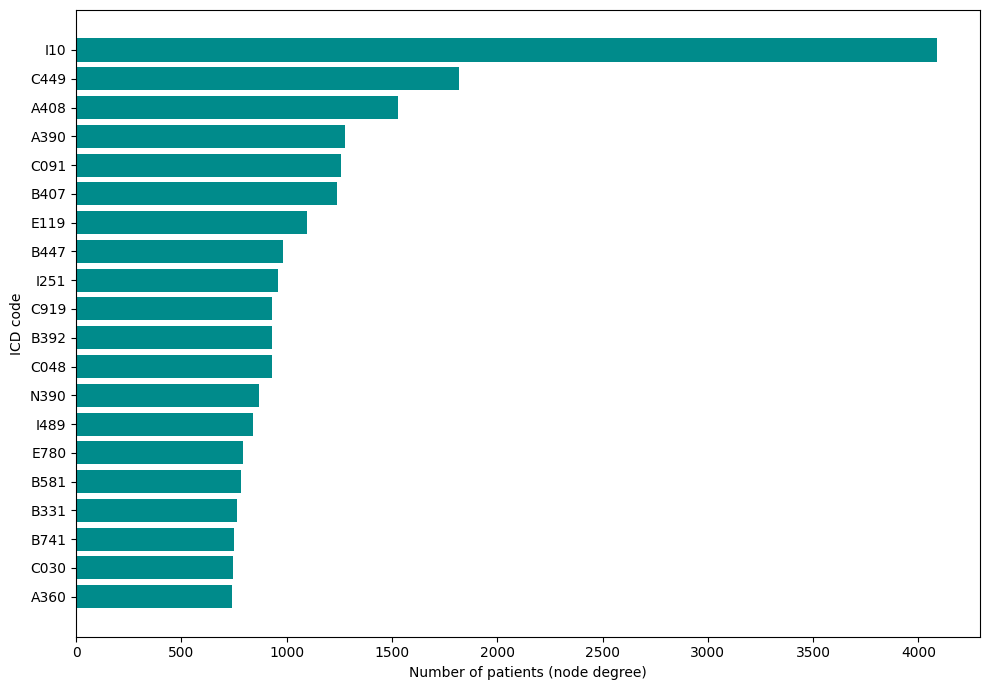

In [62]:
# Which diagnoses appear in the most patients, and which appear in the fewest patients?

top_nodes = diagnosis_frequency.head(20).sort_values("node_degree")
plt.figure(figsize=(10, 7))
plt.barh(top_nodes["icd_code"], top_nodes["node_degree"], color="darkcyan")
plt.xlabel("Number of patients (node degree)")
plt.ylabel("ICD code")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_diagnosis_nodes.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Diagnoses occurring alone versus with comorbidities


This is an incidence-based descriptive extension of node-degree analysis.

For each diagnosis vertex, the code separates two contexts:

1. single-diagnosis hyperedges: patient hyperedges whose size is 1;
2. multi-diagnosis hyperedges: patient hyperedges whose size is greater than 1.

- An isolated occurrence means that the patient's complete hyperedge contains only that diagnosis
- comorbid_percent means the percentage of patients with that diagnosis who also have at least one other retained diagnosis vertex in the same patient hyperedge.



In [63]:
membership_context = analysis_table[["patient_no", "node_id"]].merge(
    patient_edge_sizes[["patient_no", "hyperedge_size"]],
    on="patient_no",
    how="left"
)

isolated_by_node = (
    membership_context[membership_context["hyperedge_size"] == 1]
    .groupby("node_id")["patient_no"]
    .nunique()
)

isolated_vs_comorbid = diagnosis_frequency[
    ["node_id", "diagnose_id", "icd_code", "descr", "node_degree"]
].copy()

isolated_vs_comorbid["isolated_patient_count"] = (
    isolated_vs_comorbid["node_id"].map(isolated_by_node).fillna(0).astype(int)
)
isolated_vs_comorbid["comorbid_patient_count"] = (
    isolated_vs_comorbid["node_degree"] - isolated_vs_comorbid["isolated_patient_count"]
)
isolated_vs_comorbid["isolated_percent"] = (
    100 * isolated_vs_comorbid["isolated_patient_count"]
    / isolated_vs_comorbid["node_degree"]
).round(2)
isolated_vs_comorbid["comorbid_percent"] = (
    100 - isolated_vs_comorbid["isolated_percent"]
).round(2)

isolated_vs_comorbid.to_csv(OUTPUT_DIR / "isolated_vs_comorbid_diagnoses.csv", index=False)
isolated_vs_comorbid.sort_values("isolated_patient_count", ascending=False).head(20)



,node_id,diagnose_id,icd_code,descr,node_degree,isolated_patient_count,comorbid_patient_count,isolated_percent,comorbid_percent
1,874,1132,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",1818,5,1813,0.28,99.72
3,140,203,A390,Meningokokkenmeningitis(G01*),1276,3,1273,0.24,99.76
7,467,673,B447,"DisseminierteAspergillose,GeneralisierteAspergillose",981,2,979,0.20,99.80
194,6248,7445,M512,"SonstigenäherbezeichneteBandscheibenverlagerung,LumbagodurchBandscheibenverlagerung",161,1,160,0.62,99.38
17,553,801,B741,FilariosedurchBrugiamalayi,751,1,750,0.13,99.87
4,675,958,C091,BösartigeNeubildung-Gaumenbogen(vorderer)(hinterer),1256,1,1255,0.08,99.92
18,652,930,C030,BösartigeNeubildung-Oberkieferzahnfleisch,743,1,742,0.13,99.87
597,3675,4355,J91,PleuraergußbeianderenortsklassifiziertenKrankheiten,44,1,43,2.27,97.73
30,1025,1305,C767,BösartigeNeubildung-SonstigeungenaubezeichneteLokalisationen,615,1,614,0.16,99.84
31,1184,1468,D047,"Carcinomainsitu-HautderunterenExtremität,einschließlichHüfte",596,1,595,0.17,99.83


## 6. Top disease patterns / exact hyperedge patterns

Question: Which complete diagnosis sets, ICD-code sets, or patient hyperedge patterns appear most often?

This section counts **complete patient hyperedges**. Each patient contributes one sorted diagnosis set. A repeated pattern means that the same complete diagnosis-node set occurs in multiple patients.

This is more directly hypergraph-based than pairwise co-occurrence, because the full hyperedge is preserved:

- patient `{A, B, C}` contributes to exact pattern `{A, B, C}`;
- it does not separately contribute to `{A, B}`, `{A, C}`, or `{B, C}` in this exact-pattern analysis.


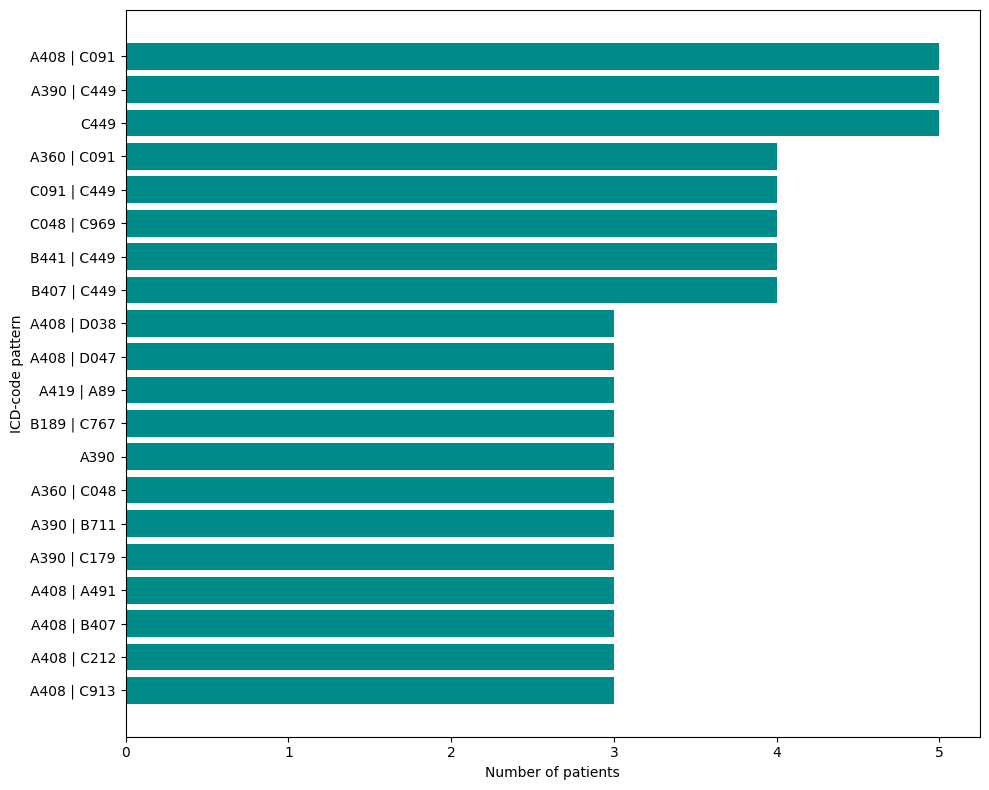

,Rank,Pattern_Size,ICD_Codes,Descriptions,Patient_Count,Percentage
0,1,1,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",5,0.02
1,2,2,A390 | C449,"Meningokokkenmeningitis(G01*) | SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",5,0.02
2,3,2,A408 | C091,SonstigeSepsisdurchStreptokokken | BösartigeNeubildung-Gaumenbogen(vorderer)(hinterer),5,0.02
3,4,2,A360 | C091,"Rachendiphtherie,Anginapseudomembranaceadiphtherica,Tonsillendiphtherie | BösartigeNeubildung-Gaumenbogen(vorderer)(...",4,0.02
4,5,2,B407 | C449,"DisseminierteBlastomykose,GeneralisierteBlastomykose | SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",4,0.02
5,6,2,B441 | C449,"SonstigeAspergillosederLunge | SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",4,0.02
6,7,2,C048 | C969,"BösartigeNeubildung-Mundboden,mehrereTeilbereicheüberlappend[SieheHinw.5-KapII:Fallsmehr.Teilber.betroffen,Ursprungs...",4,0.02
7,8,2,C091 | C449,"BösartigeNeubildung-Gaumenbogen(vorderer)(hinterer) | SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",4,0.02
8,9,1,A390,Meningokokkenmeningitis(G01*),3,0.01
9,10,2,A360 | C048,"Rachendiphtherie,Anginapseudomembranaceadiphtherica,Tonsillendiphtherie | BösartigeNeubildung-Mundboden,mehrereTeilb...",3,0.01


In [64]:
def exact_patient_patterns(df, min_size=1, max_size=20, top_n=100):
    """Rank complete patient diagnosis sets / hyperedge patterns."""

    patient_sets = (
        df.groupby("patient_no")["node_id"]
        .apply(lambda values: tuple(sorted(set(values))))
        .reset_index(name="node_set")
    )
    patient_sets["Pattern_Size"] = patient_sets["node_set"].str.len()

    eligible = patient_sets[
        patient_sets["Pattern_Size"].between(min_size, max_size)
    ]

    result = (
        eligible.groupby(["node_set", "Pattern_Size"])
        .size()
        .reset_index(name="Patient_Count")
        .sort_values(["Patient_Count", "Pattern_Size"], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )

    result["ICD_Codes"] = result["node_set"].apply(
        lambda nodes: " | ".join(str(node_lookup.loc[n, "icd_code"]) for n in nodes)
    )
    result["Descriptions"] = result["node_set"].apply(
        lambda nodes: " | ".join(str(node_lookup.loc[n, "descr"]) for n in nodes)
    )
    result["Percentage"] = (
        100 * result["Patient_Count"] / df["patient_no"].nunique()
    ).round(2)
    result.insert(0, "Rank", range(1, len(result) + 1))

    return result[
        ["Rank", "Pattern_Size", "ICD_Codes", "Descriptions", "Patient_Count", "Percentage"]
    ]


top_disease_patterns = exact_patient_patterns(
    analysis_table,
    min_size=1,
    max_size=20,
    top_n=100
)

top_disease_patterns.to_csv(OUTPUT_DIR / "top_disease_patterns.csv", index=False)

plot_patterns = top_disease_patterns.head(20).sort_values("Patient_Count")
plt.figure(figsize=(10, 8))
plt.barh(
    plot_patterns["ICD_Codes"],
    plot_patterns["Patient_Count"],
    color="darkcyan"
)
plt.xlabel("Number of patients")
plt.ylabel("ICD-code pattern")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_disease_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

top_disease_patterns.head(20)


## 10. Sex and age-group comparisons

This section constructs demographic sub-hypergraphs by grouping patient hyperedges by sex and age group.

For each group:

- patient-level measures are computed once per patient hyperedge;
- diagnosis rankings use unique patients within that demographic group;
- prevalence is therefore group-specific.

This is consistent with incidence-based hypergraph analysis: the same vertex-degree and hyperedge-size concepts are applied inside each demographic sub-hypergraph.

In [65]:
all_patient_sizes = (
    analysis_table.groupby("patient_no")["node_id"]
    .nunique().reset_index(name="n_unique_diagnoses")
    .merge(
        analysis_table[["patient_no", "sex", "age_group_10y"]].drop_duplicates("patient_no"),
        on="patient_no",
        how="left"
    )
)

group_comparison = (
    all_patient_sizes.groupby(["sex", "age_group_10y"], observed=False)
    .agg(
        n_patients=("patient_no", "nunique"),
        mean_unique_diagnoses=("n_unique_diagnoses", "mean"),
        median_unique_diagnoses=("n_unique_diagnoses", "median"),
        q25_unique_diagnoses=("n_unique_diagnoses", lambda x: x.quantile(0.25)),
        q75_unique_diagnoses=("n_unique_diagnoses", lambda x: x.quantile(0.75)),
        multimorbidity_percent=("n_unique_diagnoses", lambda x: 100 * (x >= 2).mean()),
        complex_multimorbidity_percent=("n_unique_diagnoses", lambda x: 100 * (x >= 5).mean())
    )
    .reset_index()
)

numeric_columns = group_comparison.select_dtypes(include="number").columns
group_comparison[numeric_columns] = group_comparison[numeric_columns].round(2)
group_comparison.to_csv(OUTPUT_DIR / "sex_age_group_comparison.csv", index=False)
group_comparison




,sex,age_group_10y,n_patients,mean_unique_diagnoses,median_unique_diagnoses,q25_unique_diagnoses,q75_unique_diagnoses,multimorbidity_percent,complex_multimorbidity_percent
0,Female,20-29,1565,4.74,3.0,2.0,5.0,99.87,30.80
1,Female,30-39,1386,5.46,4.0,2.0,6.0,99.86,38.89
2,Female,40-49,1424,9.81,7.0,4.0,13.0,100.00,68.82
3,Female,50-59,1607,5.74,3.0,2.0,6.0,99.94,36.96
4,Female,60-69,1024,9.95,7.0,4.0,13.0,100.00,71.09
5,Female,70+,3703,6.74,4.0,2.0,8.0,99.84,44.75
6,Male,20-29,1231,5.05,3.0,2.0,6.0,99.59,34.69
7,Male,30-39,1367,5.85,4.0,2.0,6.0,99.85,38.70
8,Male,40-49,1366,10.37,8.0,4.0,14.0,99.93,72.11
9,Male,50-59,1419,7.18,4.0,3.0,8.0,99.93,49.33


In [66]:
group_diagnosis_frequency = (
    analysis_table.groupby(
        ["sex", "age_group_10y", "node_id", "icd_code", "descr"],
        observed=True
    )["patient_no"].nunique()
    .reset_index(name="patient_count")
)

group_patient_totals = (
    analysis_table[["patient_no", "sex", "age_group_10y"]].drop_duplicates("patient_no").groupby(["sex", "age_group_10y"], observed=True)["patient_no"]
    .nunique().rename("group_patient_total").reset_index()
)

group_diagnosis_frequency = group_diagnosis_frequency.merge(
    group_patient_totals, on=["sex", "age_group_10y"], how="left"
)
group_diagnosis_frequency["prevalence_percent"] = (
    100 * group_diagnosis_frequency["patient_count"]
    / group_diagnosis_frequency["group_patient_total"]
).round(2)
group_diagnosis_frequency["rank_within_group"] = (
    group_diagnosis_frequency.groupby(["sex", "age_group_10y"], observed=True)["patient_count"]
    .rank(method="first", ascending=False)
)

top_diagnoses_by_group = group_diagnosis_frequency[
    group_diagnosis_frequency["rank_within_group"] <= 10
].sort_values(["sex", "age_group_10y", "rank_within_group"])

top_diagnoses_by_group.to_csv(OUTPUT_DIR / "top_diagnoses_by_sex_age.csv", index=False)
top_diagnoses_by_group.head(30)


,sex,age_group_10y,node_id,icd_code,descr,patient_count,group_patient_total,prevalence_percent,rank_within_group
513,Female,20-29,874,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherbezeichnet",103,1565,6.58,1.0
242,Female,20-29,455,B407,"DisseminierteBlastomykose,GeneralisierteBlastomykose",97,1565,6.20,2.0
60,Female,20-29,152,A408,SonstigeSepsisdurchStreptokokken,95,1565,6.07,3.0
54,Female,20-29,140,A390,Meningokokkenmeningitis(G01*),91,1565,5.81,4.0
391,Female,20-29,675,C091,BösartigeNeubildung-Gaumenbogen(vorderer)(hinterer),84,1565,5.37,5.0
1048,Female,20-29,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,Hypertonie(arteriell)(benigne)(essentiell)(maligne)(primär)(systemisch)",79,1565,5.05,6.0
633,Female,20-29,1116,C919,"LymphatischeLeukämie,nichtnäherbezeichnet",74,1565,4.73,7.0
238,Female,20-29,450,B392,"HistoplasmosederLungedurchHistoplasmacapsulatum,nichtnäherbezeichnet",72,1565,4.60,8.0
379,Female,20-29,657,C048,"BösartigeNeubildung-Mundboden,mehrereTeilbereicheüberlappend[SieheHinw.5-KapII:Fallsmehr.Teilber.betroffen,Ursprungs...",71,1565,4.54,9.0
249,Female,20-29,467,B447,"DisseminierteAspergillose,GeneralisierteAspergillose",59,1565,3.77,10.0


## 11. Temporal progression between different first-diagnosis dates


This section adds temporal ordering to the descriptive analysis. Same-day sets are already analysed in `FirstScript.ipynb`. 

Important interpretation:

- dates are first observed dates in the hospital-record data;
- same-day diagnosis sets are not ordered against each other;
- transitions are descriptive temporal summaries, not causal effects;


In [67]:
dated_memberships = analysis_table.dropna(subset=["first_date"]).copy()
diagnosis_events = (
    dated_memberships.groupby(["patient_no", "first_date"])["node_id"]
    .apply(lambda values: tuple(sorted(set(values))))
    .reset_index(name="event_nodes")
    .sort_values(["patient_no", "first_date"])
)

transition_counts = Counter()
transition_gaps = defaultdict(list)

for patient_no, events in diagnosis_events.groupby("patient_no", sort=False):
    records = list(events[["first_date", "event_nodes"]].itertuples(index=False, name=None))
    for (source_date, source_nodes), (target_date, target_nodes) in zip(records, records[1:]):
        gap_days = (target_date - source_date).days
        for source_node, target_node in product(source_nodes, target_nodes):
            transition_counts[(source_node, target_node)] += 1
            transition_gaps[(source_node, target_node)].append(gap_days)

temporal_transitions = pd.DataFrame([
    {
        "source_node": source,
        "source_icd": node_lookup.loc[source, "icd_code"],
        "target_node": target,
        "target_icd": node_lookup.loc[target, "icd_code"],
        "patient_transition_count": count,
        "median_gap_days": float(np.median(transition_gaps[(source, target)])),
        "mean_gap_days": float(np.mean(transition_gaps[(source, target)]))
    }
    for (source, target), count in transition_counts.items()
]).sort_values("patient_transition_count", ascending=False)

temporal_transitions.to_csv(OUTPUT_DIR / "temporal_next_event_transitions.csv", index=False)
temporal_transitions.head(30)



,source_node,source_icd,target_node,target_icd,patient_transition_count,median_gap_days,mean_gap_days
959,3103,I10,1667,E119,112,179.0,313.669643
2414,3103,I10,1899,E785,102,187.5,296.009804
1606,3103,I10,3144,I251,93,139.0,276.537634
1092,3103,I10,1894,E780,89,155.0,273.853933
3925,3103,I10,3255,I489,88,218.5,325.147727
8945,3103,I10,3250,I480,80,153.5,316.137500
373,3103,I10,8236,N390,80,139.5,273.462500
5216,3103,I10,3151,I259,75,183.0,297.013333
585,3103,I10,8171,N189,71,129.0,249.394366
4665,1667,E119,3103,I10,63,232.0,301.285714


In [ ]:
#output_table = pd.DataFrame({
 #   "file": sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
#})
#output_table

,file
0,diagnosis_frequency.csv
1,edge_sizes.png
2,hyperedge_size_binned.csv
3,hyperedge_size_distribution.csv
4,hypergraph_overview.csv
5,isolated_vs_comorbid_diagnoses.csv
6,multimorbidity_summary.csv
7,sex_age_group_comparison.csv
8,sex_diagnosis_frequency.csv
9,sex_edge_sizes.csv
